In [171]:
import numpy as np
import pandas as pd
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))


/kaggle/input/digit-recognizer/sample_submission.csv
/kaggle/input/digit-recognizer/train.csv
/kaggle/input/digit-recognizer/test.csv


## **MNIST** dataset for digit recognition
- shape of one image is 20x28=784 + 1(label). Each pixel is a column in our dataset.

#### **Steps of PAC**
- Mean Centerized data (Standardize the Data): `X - mean`
- Compute the Covariance Matrix : `np.cov(X.T)`
- Compute Eigenvalues and Eigenvectors : `eig(cov)`
- Sort Eignevalues and Eigenvectors : `argsort()`
- Select Top `k` Principal Components : `[:, :k]`
- Transform the Data (Project data onto new axis) : `X.dot(V)`

### <font color="blue">**Step 1:** ***Normal Model Prediction without PCA***</font>

In [172]:
df = pd.read_csv("/kaggle/input/digit-recognizer/train.csv")
df.head()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [173]:
df.shape

(42000, 785)

In [174]:
df.describe()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
count,42000.000000,42000.0,42000.0,42000.0,42000.0,42000.0,42000.0,42000.0,42000.0,42000.0,...,42000.000000,42000.000000,42000.000000,42000.00000,42000.000000,42000.000000,42000.0,42000.0,42000.0,42000.0
mean,4.456643,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.219286,0.117095,0.059024,0.02019,0.017238,0.002857,0.0,0.0,0.0,0.0
std,2.887730,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,6.312890,4.633819,3.274488,1.75987,1.894498,0.414264,0.0,0.0,0.0,0.0
min,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.0,0.0,0.0,0.0
25%,2.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.0,0.0,0.0,0.0
50%,4.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.0,0.0,0.0,0.0
75%,7.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.0,0.0,0.0,0.0
max,9.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,254.000000,254.000000,253.000000,253.00000,254.000000,62.000000,0.0,0.0,0.0,0.0


In [175]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42000 entries, 0 to 41999
Columns: 785 entries, label to pixel783
dtypes: int64(785)
memory usage: 251.5 MB


Label:  8


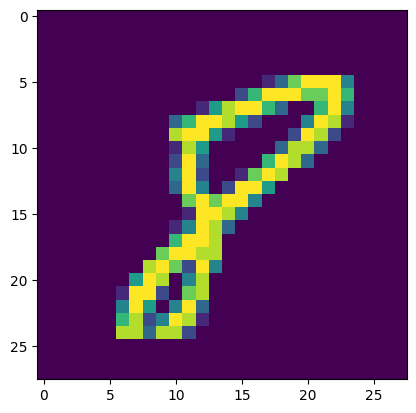

In [176]:
import matplotlib.pyplot as plt
digit_img = df.iloc[18306,1:].values.reshape(28, 28)
print("Label: ", df.iloc[18306, 0]) #label
plt.imshow(digit_img)


Label:  4


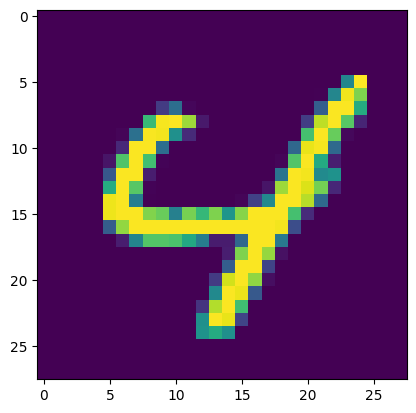

In [177]:
digit_img = df.iloc[18284,1:].values.reshape(28, 28)
print("Label: ", df.iloc[18284, 0]) #label
plt.imshow(digit_img)

Label:  6


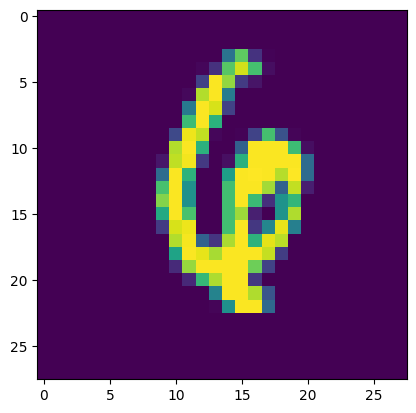

In [178]:
digit_img = df.iloc[15045,1:].values.reshape(28, 28)
print("Label: ", df.iloc[15045, 0]) #label
plt.imshow(digit_img)

In [179]:
# X(features) and y(labels) extract
X = df.iloc[:, 1:] # features
y = df.iloc[:, 0] # label

In [180]:
# train test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((33600, 784), (33600,), (8400, 784), (8400,))

In [181]:
# Model import
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier()

# fit the model
knn.fit(X_train, y_train)

KNeighborsClassifier()

In [182]:
# Predict
import time
start = time.time()
y_pred = knn.predict(X_test)
end = time.time()
print("Execution time: ", end-start)
y_pred.shape

Execution time:  13.635793447494507


(8400,)

In [183]:
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test, y_pred) * 100
round(accuracy, 3)

96.488

### <font color="blue">**Step 2:** ***Model Prediction with PCA***</font>
#### **Steps of PAC**
- Mean Centerized data (Standardize the Data): `X - mean`
- Compute the Covariance Matrix : `np.cov(X.T)`
- Compute Eigenvalues and Eigenvectors : `eig(cov)`
- Sort Eignevalues and Eigenvectors : `argsort()`
- Select Top `k` Principal Components : `[:, :k]`
- Transform the Data (Project data onto new axis) : `X.dot(V)`

In [184]:
# X(features) and y(labels) extract
X = df.iloc[:, 1:] # features
y = df.iloc[:, 0] # label

In [185]:
# train test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((33600, 784), (33600,), (8400, 784), (8400,))

In [186]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

# Mean centering
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled.shape

(33600, 784)

In [187]:
# PCA
from sklearn.decomposition import PCA
# pca = PCA(n_components=None)
pca = PCA(n_components=100)

X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

X_train_pca.shape

(33600, 100)

In [188]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier()
knn.fit(X_train_pca, y_train)

KNeighborsClassifier()

In [189]:
import time
start = time.time()
y_predict = knn.predict(X_test_pca)
end = time.time()
print("Execution Time: ", end-start)
y_predict.shape

Execution Time:  1.7450780868530273


(8400,)

In [190]:
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test, y_predict) * 100
round(accuracy, 3)

95.321

### **<font color="green">Check PCA in a Loop</font>**

In [191]:
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
import time

# Load the dataset
df = pd.read_csv("/kaggle/input/digit-recognizer/train.csv")

# Extract features and labels
X = df.iloc[:, 1:]  # Features (pixels)
y = df.iloc[:, 0]   # Labels (digit classes)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create a pipeline with StandardScaler, PCA, and KNN
pipeline = Pipeline([
    ('scaler', StandardScaler()),  # Add scaling step
    ('pca', PCA()),
    ('knn', KNeighborsClassifier())
])

# Lists to store results for potential plotting
components = []
accuracies = []
times = []

# Loop over different numbers of PCA components
for i in range(1, 785, 50):
    # Set the number of components for PCA in the pipeline
    pipeline.set_params(pca__n_components=i)
    
    start = time.time()
    pipeline.fit(X_train, y_train)
    y_predict = pipeline.predict(X_test)
    end = time.time()
    
    # Calculate accuracy
    accuracy = accuracy_score(y_test, y_predict) * 100
    
    # Store results
    components.append(i)
    accuracies.append(accuracy)
    times.append(end - start)
    
    # Print results
    print(f"PCA components: {i}, Accuracy: {round(accuracy, 3)}%, Execution Time: {round(end - start, 3)} seconds")


In [192]:
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
import plotly.express as px
import time

# Load the dataset
df = pd.read_csv("/kaggle/input/digit-recognizer/train.csv")

# Extract features and labels
X = df.iloc[:, 1:]
y = df.iloc[:, 0]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Mean centering
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Perform PCA
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

# Convert labels to string for coloring
y_train_pca = y_train.astype(str)

# Plot using Plotly
fig = px.scatter(
    x=X_train_pca[:, 0],
    y=X_train_pca[:, 1],
    color=y_train_pca,
    color_discrete_sequence=pc.qualitative.G10  # Correct usage
)
fig.show()


In [193]:
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
import plotly.express as px
import time

# Load the dataset
df = pd.read_csv("/kaggle/input/digit-recognizer/train.csv")

# Extract features and labels
X = df.iloc[:, 1:]
y = df.iloc[:, 0]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Mean centering
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Perform PCA
pca = PCA(n_components=3)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

# Convert labels to string for coloring
y_train_pca = y_train.astype(str)

# 3D scatter plot using Plotly
fig = px.scatter_3d(
    x=X_train_pca[:, 0],
    y=X_train_pca[:, 1],
    z=X_train_pca[:, 2],
    color=y_train_pca,
    color_discrete_sequence=pc.qualitative.G10
)
fig.show()


In [199]:
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import time

# Load the dataset
df = pd.read_csv("/kaggle/input/digit-recognizer/train.csv")

# Extract features and labels
X = df.iloc[:, 1:]
y = df.iloc[:, 0] 

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Mean centering
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Perform PCA
pca = PCA(n_components=3)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

print("Variance(Eigen Value): ", pca.explained_variance_)
print("Component(Eigen Vector): ", pca.components_)
print("Component Shape: ", pca.components_.shape)


Variance(Eigen Value):  [335506.57619109 244807.1039101  212051.03372877]
Component(Eigen Vector):  [[ 7.94369865e-18 -2.62537577e-18  9.95945833e-19 ... -0.00000000e+00
  -0.00000000e+00 -0.00000000e+00]
 [-4.52121650e-17  1.94905674e-17 -5.65430406e-18 ... -0.00000000e+00
  -0.00000000e+00 -0.00000000e+00]
 [-6.76214959e-17  6.96993272e-18 -1.98322301e-17 ... -0.00000000e+00
  -0.00000000e+00 -0.00000000e+00]]
Component Shape:  (3, 784)
